# Baseline model

In [1]:
# To run this model notebook, first run Elias_create_train_val_test_datasets.ipynb to create the datasets, then copy the printed paths and paste them below
train_data_dir = '/Users/et/code/Lucia-Cordero/ReefSight-Project/raw_data/image_data/train_validation_test/train'
val_data_dir = '/Users/et/code/Lucia-Cordero/ReefSight-Project/raw_data/image_data/train_validation_test/val'
test_data_dir = '/Users/et/code/Lucia-Cordero/ReefSight-Project/raw_data/image_data/train_validation_test/test'

# Additionally, define path to save model
model_path = '/Users/et/code/Lucia-Cordero/ReefSight-Project/models'

Found 280 files belonging to 2 classes.
Found 92 files belonging to 2 classes.
Found 96 files belonging to 2 classes.
Class names train dataset: ['Bleached', 'Unbleached']
Class names validation dataset: ['Bleached', 'Unbleached']
Class names test dataset: ['Bleached', 'Unbleached']


/Users/et/.pyenv/versions/3.10.6/envs/ReefSight-Project/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,515,905 (24.86 MB)

 Trainable params: 6,515,905 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.6179 - loss: 1.0951 - val_accuracy: 0.5000 - val_loss: 0.6303 - learning_rate: 0.0030
Epoch 2/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.7357 - loss: 0.5436 - val_accuracy: 0.7609 - val_loss: 0.4778 - learning_rate: 0.0030
Epoch 3/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.8000 - loss: 0.4713 - val_accuracy: 0.8261 - val_loss: 0.4717 - learning_rate: 0.0030
Epoch 4/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.8143 - loss: 0.4651 - val_accuracy: 0.8370 - val_loss: 0.3915 - learning_rate: 0.0030
Epoch 5/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step - accuracy: 0.8250 - loss: 0.3882 - val_accuracy: 0.8043 - val_loss: 0.4121 - learning_rate: 0.0030
Epoch 6/1000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8715 - loss: 0.3425
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.001500000013038516.
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.8643 - loss:

2025-12-16 17:34:42.233758: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


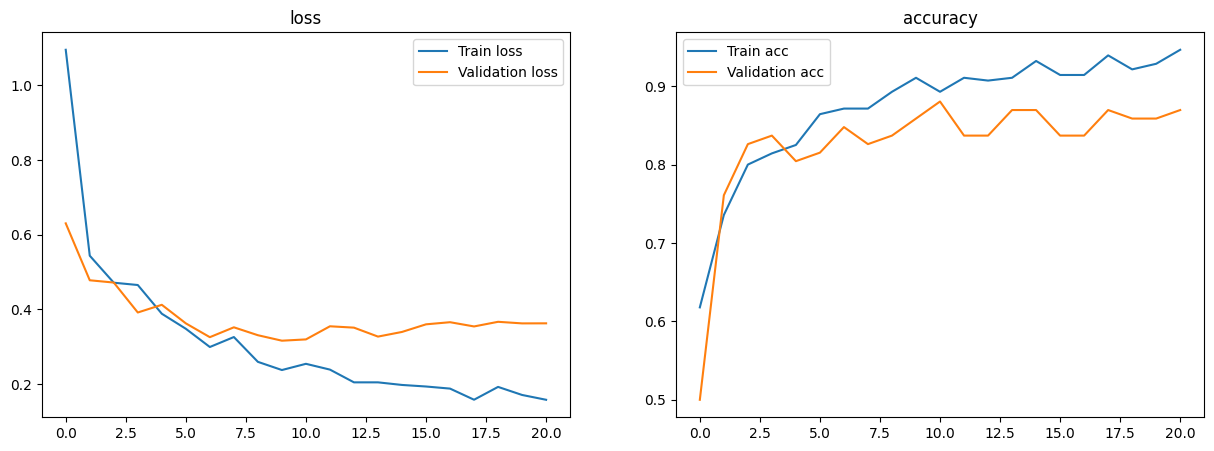

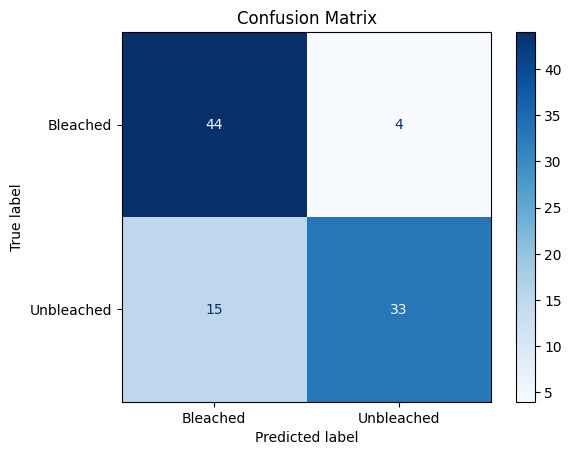

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import layers, models, regularizers
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Constants
batch_size = 16
seed = 42
image_size = (224, 224)
input_shape = image_size + (3,)
num_classes = 2
learning_rate = 0.003

## Load datasets
train_ds = image_dataset_from_directory(
    train_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    val_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

test_ds = image_dataset_from_directory(
    test_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

print("Class names train dataset:", train_ds.class_names)
print("Class names validation dataset:", val_ds.class_names)
print("Class names test dataset:", test_ds.class_names)

## Built and compile model
def create_baseline_cnn(input_shape, num_classes=2, learning_rate=0.001):

    # Build the model
    model = Sequential()

    # Normalize pixel values to [0,1] inside the model so saved model includes preprocessing
    model.add(layers.Rescaling(1./255, input_shape=input_shape))

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding="same"))
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding="same"))
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding="same"))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Flatten())

    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile the model
    adam = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=adam, loss='binary_crossentropy', metrics=['accuracy'])

    return model

baseline_model = create_baseline_cnn(input_shape, num_classes, learning_rate)
baseline_model.summary()

# Configure callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                     patience=10,
                                     restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(os.path.join(model_path, 'baseline_image_model.keras'),
                                       monitor='val_accuracy',
                                       save_best_only=True), # What does ModelCheckpoint do?
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy',
                                         factor=0.5,
                                         patience=2,
                                         verbose=1), # What does ReduceLROnPlateau do?
]

## Train using datasets
epochs = 1000

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
)

## Plot training history
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    ax[1].set_title('accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation acc")
    ax[0].legend()
    ax[1].legend()

plot_history(history)

## Evaluate the model on the val dataset
test_loss, test_accuracy = baseline_model.evaluate(val_ds)

print(f"Val Loss: {test_loss}")
print(f"Val Accuracy: {test_accuracy}")

## Evaluate the model on the test dataset
test_loss, test_accuracy = baseline_model.evaluate(test_ds)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

## Plot confusion matrix
y_true = []
y_pred = []

# Iterate through the test dataset to collect predictions
for images, labels in test_ds:
    y_true.extend(labels)  # Assuming labels are already in a format compatible with y_true
    predictions = baseline_model.predict(images)
    # For binary classification, use a threshold of 0.5 to determine class
    predicted_class = (predictions > 0.5).astype(int)  # Convert probabilities to class labels
    y_pred.extend(predicted_class)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_ds.class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Load model and predict

Randomly selected image: 166.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Probability Unbleached: 0.11913967877626419
Probability Bleached: 0.8808603286743164
Predicted class index: 0
Class names test dataset: ['Bleached', 'Unbleached']
Predicted class: Bleached


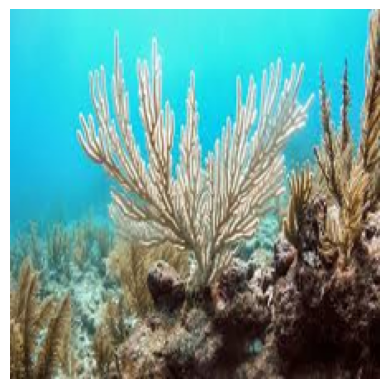

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
True classes: ['Bleached', 'Unbleached', 'Unbleached', 'Unbleached', 'Unbleached', 'Unbleached', 'Unbleached', 'Unbleached', 'Bleached', 'Bleached', 'Unbleached', 'Bleached', 'Bleached', 'Unbleached', 'Bleached', 'Unbleached']
Predicted classes: ['Bleached', 'Unbleached', 'Unbleached', 'Bleached', 'Unbleached', 'Unbleached', 'Bleached', 'Unbleached', 'Bleached', 'Bleached', 'Unbleached', 'Unbleached', 'Bleached', 'Unbleached', 'Bleached', 'Unbleached']


/var/folders/d9/v5_06vd52pj5h82bcx8qbzbm0000gn/T/ipykernel_15252/3375298309.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob_unbleached = float(preds[i])


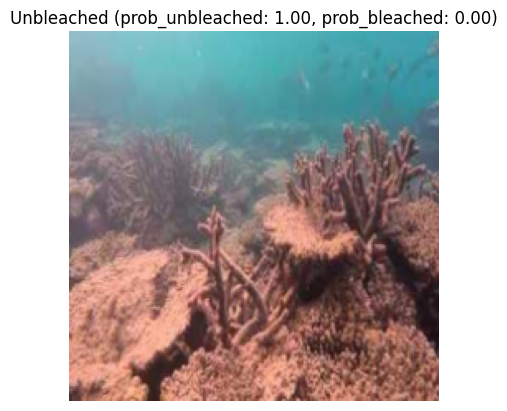

In [3]:
## Load model

model_loaded = tf.keras.models.load_model(os.path.join('/Users/et/code/Lucia-Cordero/ReefSight-Project/models', 'baseline_image_model.keras'))

## Make predictions on a single image from the test dataset
from tensorflow.keras.preprocessing import image
import random

# List all files in the directory
image_files_bleached = [f for f in os.listdir(test_data_dir + '/Bleached') if os.path.isfile(os.path.join(test_data_dir + '/Bleached', f))]
image_files_unbleached = [f for f in os.listdir(test_data_dir + '/Unbleached') if os.path.isfile(os.path.join(test_data_dir + '/Unbleached', f))]

# Select a random image file
random_image = random.choice(image_files_bleached)

print(f'Randomly selected image: {random_image}')

# Load the image
img_path = test_data_dir + '/Bleached/' + random_image
img = image.load_img(img_path, target_size=(224, 224))
img.convert('RGB')  # Ensure image is in RGB format
img_array = image.img_to_array(img)
#img_array /= 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
predictions = model_loaded.predict(img_array)
print(f"Probability Unbleached: {predictions[0][0]}")
print(f"Probability Bleached: {1-predictions[0][0]}")

predicted_class = (predictions[0][0] >= 0.5).astype("int32")
print(f"Predicted class index: {predicted_class}")

class_names = test_ds.class_names
print(f"Class names test dataset:", test_ds.class_names)

predicted_label = class_names[predicted_class]
print(f"Predicted class: {predicted_label}")

# Visualize the image
plt.imshow(img)
plt.axis('off')
plt.show()

## Alternatively, make predictions on a batch of images from the test dataset

#Displaying predicstions vs true labels for 1 batch in test_set
for images, labels in test_ds.take(1):
    preds = model_loaded.predict(images)
    # Convert tensors to arrays
    true_labels = labels.numpy().astype(int).reshape(-1)
    pred_labels = (preds > 0.5).astype(int).reshape(-1)
    probs = preds.reshape(-1) # flattent to 1D
    break
# Map numeric labels → class names
class_names = test_ds.class_names
true_class_names = [class_names[i] for i in true_labels]
pred_class_names = [class_names[i] for i in pred_labels]
print("True classes:", true_class_names)
print("Predicted classes:", pred_class_names)


#Displaying one image with readable class names
import matplotlib.pyplot as plt
i = 11  # choose image index
pred_class_name = class_names[pred_labels[i]]
prob_unbleached = float(preds[i])
prob_bleached = 1 - prob_unbleached
plt.imshow(images[i].numpy().astype("uint8"))
plt.title(f"{pred_class_name} (prob_unbleached: {prob_unbleached:.2f}, prob_bleached: {prob_bleached:.2f})")
plt.axis("off")
plt.show()